# Project Title: Fashion -MNIST Clothing Classification

## Problem Statement
  Given a dataset of 28×28 grayscale images of clothing items from the Fashion-MNIST dataset, the objective is to develop a classification model that accurately predicts the category label (such as bag,T-shirt, shoe etc.) for each image.

# Dataset Used:
The dataset used is the Fashion-MNIST dataset, which consists of 70,000 grayscale images of fashion products, divided into 60,000 training samples and 10,000 test samples.

## Objective
1. Maximize Classification Accuracy
2. Minimize Prediction error

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
import pandas as pd
import torchvision

SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
  memory = torch.cuda.get_device_properties(0).total_memory / 1e9
  print(f"Device : {device}")
  print(f"Torch version: {torch.__version__}")
  print(f"Memory: {memory} GB")
else:
  print(f"Device: {device}")


Device : cuda
Torch version: 2.10.0+cu128
Memory: 15.637086208 GB


# Load Data and Pre Processing Steps

In [14]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root ='./data', train= False, download=True,transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
Classes = train_dataset.classes

print(f"Train sample: {len(train_dataset)}")
print(f"Test sample: {len(test_dataset)}")
print(f"Classes: {Classes}")
print(f"No of Classes: {len(Classes)}")

Train sample: 60000
Test sample: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
No of Classes: 10


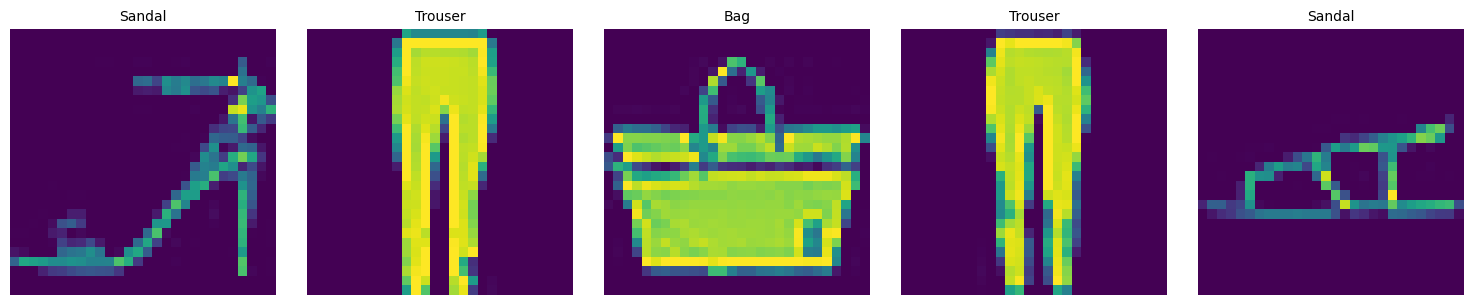

In [20]:
from torch.utils import data
# Function to show image
batch_size = 5

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()

    if npimg.shape[0] == 1:
        plt.imshow(npimg.squeeze(), cmap='gray')
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.axis('off')

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, batch_size, figsize=(15, 3))

for idx in range(batch_size):
    img = images[idx]
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()

    axes[idx].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[idx].set_title(Classes[labels[idx]], fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Model Used (CNN)

In [34]:
class Fashion_MNIST_CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(32,64,kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*3*3, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 10)
    )

  def forward(self, x):
      x = self.block1(x)
      x = self.block2(x)
      x = self.block3(x)
      x = self.classifier(x)
      return x

model = Fashion_MNIST_CNN().to(device)
print(model)

Fashion_MNIST_CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, 

## Training Setup

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, loader,loss_fn, optimizer, device):
  model.train()
  total_loss, correct = 0,0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()

  avg_loss = total_loss / len(loader)
  accuracy = 100 * correct / len(loader.dataset)
  return avg_loss, accuracy

In [36]:
def evaluate(model, loader, loss_fn, device):
  model.eval()
  total_loss, correct = 0,0

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = loss_fn(outputs, labels)

      total_loss += loss.item()
      correct += (outputs.argmax(1) == labels).sum().item()

  avg_loss = total_loss / len(loader)
  accuracy = 100 * correct / len(loader.dataset)
  return avg_loss, accuracy

## Result

In [40]:
Epochs = 10
best_test_loss = float('inf')
patience = 3
patience_counter = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(1, Epochs+1):
  train_loss, train_acc = train(model, train_loader, loss_fn, optimizer, device)
  test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['test_loss'].append(test_loss)
  history['test_acc'].append(test_acc)

  if epoch % 2 == 0:
    print(f"Epoch: {epoch:2d}/{Epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")

  if test_loss < best_test_loss:
    best_test_loss = test_loss
    patience_counter = 0
    torch.save(model.state_dict(), "best_model.pth")
  else:
    patience_counter += 1

  if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch:  2/10 | Train Loss: 0.0464 | Train Acc: 98.33% | Test Loss: 0.4343 | Test Acc: 92.21
Epoch:  4/10 | Train Loss: 0.0426 | Train Acc: 98.42% | Test Loss: 0.4587 | Test Acc: 91.72
Early stopping triggered


## Visualization

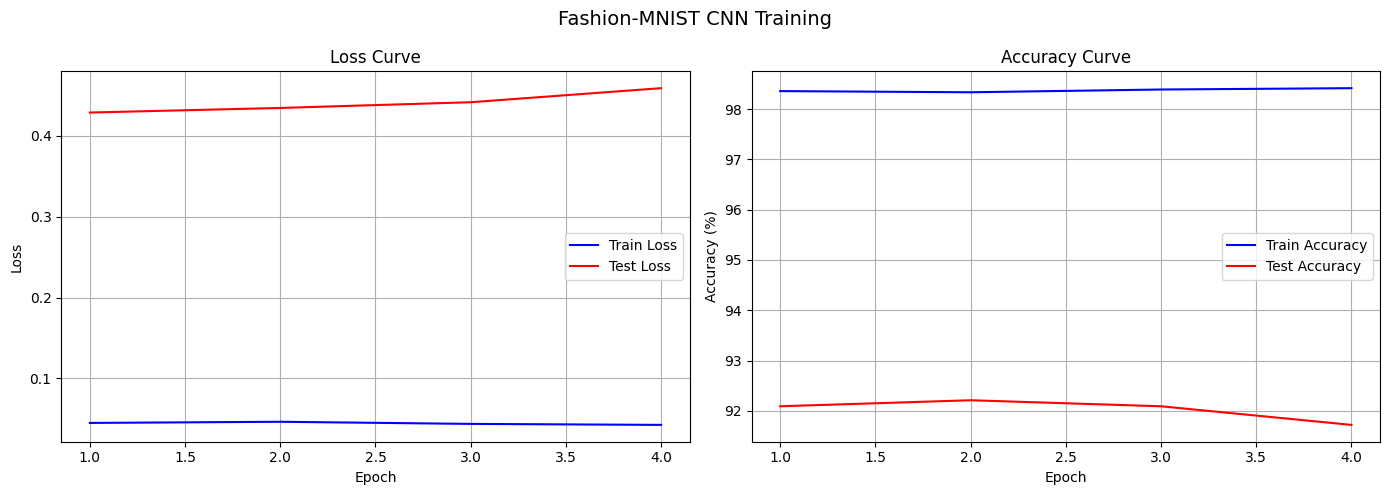

In [42]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='blue')
ax1.plot(epochs, history['test_loss'],  label='Test Loss',  color='red')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(epochs, history['test_acc'],  label='Test Accuracy',  color='red')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Fashion-MNIST CNN Training', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

<Figure size 800x800 with 0 Axes>

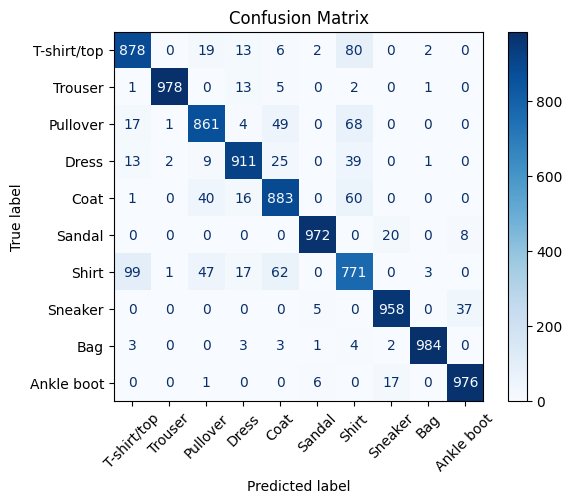

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Classes)
plt.figure(figsize=(8, 8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Error Analysis

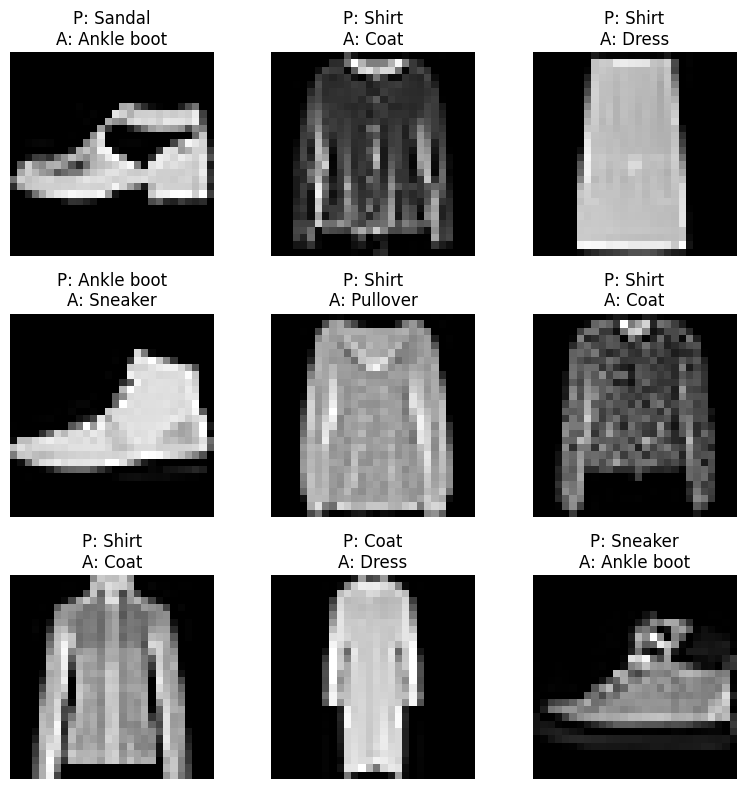

In [55]:
wrong_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        preds = outputs.argmax(1)
        for i in range(len(images)):
            if preds[i] != labels[i]:
                wrong_preds.append((images[i].cpu(), preds[i].cpu(), labels[i].cpu()))
        if len(wrong_preds) >= 9:
            break

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, (img, pred, actual) in enumerate(wrong_preds[:9]):
    row = i // 3
    col = i % 3

    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f"P: {Classes[pred]}\nA: {Classes[actual]}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Conclusion
The CNN model achieved around 98% accuracy on Fashion-MNIST and performed well overall, but struggled with similar classes like shirts and t-shirts, ankle-boot and sneaker, shirt and coat etc. Techniques like dropout and early stopping helped reduce overfitting, and future improvements can include better architectures and data augmentation.